
# **Teroria y práctica**
**Curso:** Administración actuarial del Riesgo  
**Propósito:** Entregar a los alumnos una guía **robusta y didáctica** con:
- **P1:** Offset en GLM de Poisson (teoría + demo breve).
- **P2:** Sobredispersión (diagnóstico y tratamientos).
- **P3:** Cálculo reproducible de **frecuencia bruta agregada**.
- **P4:** **GLM de Poisson con offset** (predicción, interpretación y diagnóstico), con alternativa **Binomial Negativa**.




## **Índice**
1. [Preparación y carga de datos](#prep)
2. [P1 — Offset en GLM de Poisson](#p1)
3. [P2 — Sobredispersión: diagnóstico y remedios](#p2)
4. [P3 — Frecuencia bruta agregada](#p3)
5. [P4 — GLM de Poisson con offset (y NB)](#p4)
6. [Checklist de buenas prácticas](#chk)



<a id="prep"></a>
## 0) Preparación y carga de datos
- Intentamos cargar `base_trabajo.pkl` 
- Normalizamos nombres de columnas a: `expo`, `nclaims`, `ageph`, `use`, `zone`.


In [4]:

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm, statsmodels.formula.api as smf
from patsy import bs

plt.rcParams["figure.figsize"] = (7,4)
DATA_DIR = ""

def load_base_trabajo():
    bt_path = os.path.join(DATA_DIR, "base_trabajo.pkl")
    vigor_path = os.path.join(DATA_DIR, "vigor.csv")
    sin_path = os.path.join(DATA_DIR, "siniestros.csv")
    # 1) base_trabajo.pkl
    if os.path.exists(bt_path):
        try:
            bt = pd.read_pickle(bt_path)
            print("Cargado base_trabajo desde:", bt_path)
            return bt, "base_trabajo.pkl"
        except Exception as e:
            print("No se pudo leer base_trabajo.pkl:", e)

base_trabajo, origen = load_base_trabajo()

# Normalizar nombres
df = base_trabajo.copy()
if "EXPO" in df.columns: df.rename(columns={"EXPO":"expo"}, inplace=True)
if "num_sin" in df.columns: df.rename(columns={"num_sin":"nclaims"}, inplace=True)
if "EDAD_CONDUCTOR" in df.columns: df.rename(columns={"EDAD_CONDUCTOR":"ageph"}, inplace=True)
if "USO" in df.columns: df.rename(columns={"USO":"use"}, inplace=True)
if "ZONA" in df.columns: df.rename(columns={"ZONA":"zone"}, inplace=True)

if "expo" not in df.columns: df["expo"] = 1.0
df = df[df["expo"]>0].copy()

print("Origen de datos:", origen)
print("Tamaño:", df.shape)
print("Columnas:", list(df.columns))
df.head()


Cargado base_trabajo desde: base_trabajo.pkl
Origen de datos: base_trabajo.pkl
Tamaño: (50000, 14)
Columnas: ['NUMPOL', 'expo', 'zone', 'POTENCIA', 'ANTIGUEDAD_VEHICULO', 'ageph', 'BONO', 'MARCA', 'COMBUSTIBLE', 'DENSIDAD', 'REGION', 'COD_COBERTURA', 'MONTO', 'nclaims']


,NUMPOL,expo,zone,POTENCIA,ANTIGUEDAD_VEHICULO,ageph,BONO,MARCA,COMBUSTIBLE,DENSIDAD,REGION,COD_COBERTURA,MONTO,nclaims
0,27,0.87,C,7,0,56,50,12,D,93,13,NaN,NaN,0
1,115,0.72,D,5,0,45,50,12,E,54,13,NaN,NaN,0
2,121,0.05,C,6,0,37,55,12,D,11,13,NaN,NaN,0
3,142,0.90,C,10,10,42,50,12,D,93,13,NaN,NaN,0
4,155,0.12,C,7,0,59,50,12,E,73,13,NaN,NaN,0



<a id="p1"></a>
## 1) P1 — Offset en GLM de Poisson (teoría + mini demo)

**Modelo:**  
$$
\log \mathbb{E}[N_i] \;=\; \beta_0 + \beta^\top X_i \;+\; \log(\text{expo}_i)
$$  

- El término $\log(\text{expo}_i)$ entra como **offset** con coeficiente fijo = 1.  
- Se estiman **tasas** por unidad de exposición y luego se escalan por $\text{expo}_i$.  
- $\exp(\beta_0)$ ≈ **tasa base**; $\exp(\beta_j)$= **relatividades** (rating).

**Ejemplo (autos):** si $\exp(\beta_0)=0.07$, la tasa base es 0.07 siniestros por vehículo–año; para 0.5 vehículo–año se espera $0.07\times 0.5 = 0.035$.


In [10]:
import numpy as np, pandas as pd, statsmodels.api as sm, statsmodels.formula.api as smf

toy = pd.DataFrame({
    "expo":[1.0, 0.5, 1.2, 0.8],
    "N":[2, 0,2 , 1]  # <- al menos un evento
})

m = smf.glm("N ~ 1", data=toy,
            family=sm.families.Poisson(),
            offset=np.log(toy["expo"])
           ).fit()

rate_hat = float(np.exp(m.params["Intercept"]))
print("Tasa base estimada:", rate_hat)

# Chequeo teórico: sum(N)/sum(expo)
print("Chequeo sum(N)/sum(expo):", toy["N"].sum()/toy["expo"].sum())


Tasa base estimada: 1.4285714286296356
Chequeo sum(N)/sum(expo): 1.4285714285714286



<a id="p2"></a>
## 2) P2 — Sobredispersión: diagnóstico y remedios

**Definición:** varianza observada ≫ media, violando Poisson ($\operatorname{Var}(Y)=\mathbb{E}[Y]$).  
**Diagnóstico:** $\text{Deviance}/\text{df} \gg 1$, $\chi^2_{\text{Pearson}}/\text{df} \gg 1$, exceso de ceros, residuos altos.  
**Causas:** heterogeneidad no capturada, dependencia, mezcla de riesgos, exceso de ceros estructurales.

**Tratamientos:**  
1) **Quasi–Poisson (QP):** reescala **errores estándar** (misma $\hat\mu$).  
2) **Binomial Negativa (NB):** $\operatorname{Var}(Y)=\mu+\alpha\mu^2$.  
3) **ZIP/ZINB:** mezcla con componente de “cero seguro”.

**Criterio práctico:**  
- **Exceso de ceros** ⇒ probar ZIP/ZINB.  
- **Varianza creciente con la media** ⇒ NB.  
- **Inferencia robusta rápida** ⇒ QP.



<a id="p3"></a>
## 3) P3 — Frecuencia bruta agregada

**Definición:**  
$$
\hat{\lambda} \;=\; \frac{\sum_i n_i}{\sum_i \text{expo}_i}
$$  
donde $n_i$ es el número de siniestros y $\text{expo}_i$ la exposición.  
**Lectura:** tasa promedio de siniestros por unidad de exposición (p. ej., siniestros por vehículo–año).


In [11]:

lam_hat = df["nclaims"].sum() / df["expo"].sum()
print(f"Tasa agregada λ̂ = {lam_hat:.6f} siniestros / unidad de exposición")
pd.DataFrame({
    "suma_nclaims":[df["nclaims"].sum()],
    "suma_expo":[df["expo"].sum()],
    "lambda_hat":[lam_hat]
})


Tasa agregada λ̂ = 0.072793 siniestros / unidad de exposición


,suma_nclaims,suma_expo,lambda_hat
0,1924,26431.132502,0.072793



**Notas de calidad:** conservar pólizas sin siniestro (**left join**), filtrar exposiciones ≤ 0 y usar $\hat\lambda$ como **benchmark** de orden de magnitud.



<a id="p4"></a>
## 5) P4 — GLM de Poisson con offset (predicción, interpretación y NB)

**Modelo:**  
$$
\log \mathbb{E}[N_i] = \beta_0 + \beta_1 \cdot f(\text{ageph}_i) + \log(\text{expo}_i).
$$  
- $f(\cdot)$ = función (lineal, polinómica, spline, categórica).  
- Predicción: $\hat{N}_i = \hat{\lambda}_i \cdot \text{expo}_i$, donde $\hat{\lambda}_i = \exp(\hat{\beta}_0 + \hat{\beta}_1 \cdot f(\text{ageph}_i))$.  
- Offset = `log(expo)`.  
- $\exp(\beta_0)$ ≈ tasa base; $\exp(\beta_j)$ = relatividades.


In [12]:

has_age = "ageph" in df.columns
formula = "nclaims ~ 1"
if has_age:
    formula = "nclaims ~ bs(ageph, df=6)"  # splines para flexibilidad

mod_pois = smf.glm(formula=formula,
                   data=df,
                   family=sm.families.Poisson(),
                   offset=np.log(df["expo"])).fit()
print(mod_pois.summary())

beta0 = mod_pois.params["Intercept"]
print(f"\nexp(Intercept) ≈ tasa base = {np.exp(beta0):.6f} por unidad de exposición")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                nclaims   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49993
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8136.9
Date:                Wed, 08 Oct 2025   Deviance:                       12603.
Time:                        13:17:39   Pearson chi2:                 9.69e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.001535
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.5507      0

### 5.1 Predicción por edad (si está disponible)

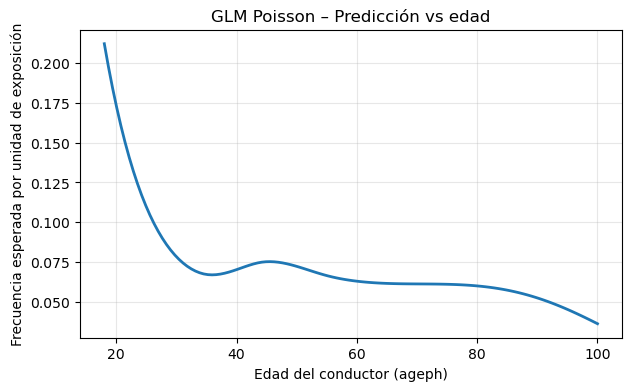

In [13]:

if has_age:
    grid = pd.DataFrame({
        "ageph": np.linspace(df["ageph"].min(), df["ageph"].max(), 120),
        "expo": 1.0
    })
    mu_hat = mod_pois.predict(grid, offset=np.log(grid["expo"]))
    import matplotlib.pyplot as plt
    plt.plot(grid["ageph"], mu_hat, lw=2)
    plt.xlabel("Edad del conductor (ageph)")
    plt.ylabel("Frecuencia esperada por unidad de exposición")
    plt.title("GLM Poisson – Predicción vs edad")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No existe 'ageph' en los datos; se omite la gráfica.")



### 5.2 Sobredispersión (indicio) y alternativa NB
Si `Deviance/df` o `Pearson/df` ≫ 1, considerar **Quasi-Poisson** o **Binomial Negativa (NB)**.


In [15]:

pearson_over_df = mod_pois.pearson_chi2 / mod_pois.df_resid
deviance_over_df = mod_pois.deviance / mod_pois.df_resid
print({"Pearson/df": pearson_over_df, "Deviance/df": deviance_over_df})

from statsmodels.genmod.families import NegativeBinomial
alpha_guess = max(pearson_over_df - 1.0, 1e-6)  # heurístico
mod_nb = smf.glm(formula=formula,
                 data=df,
                 family=NegativeBinomial(alpha=alpha_guess),
                 offset=np.log(df["expo"])).fit()
print("\n--- GLM Binomial Negativa (alpha heurístico) ---")
print(mod_nb.summary())


beta0 = mod_nb.params["Intercept"]
print(f"\nexp(Intercept) ≈ tasa base = {np.exp(beta0):.6f} por unidad de exposición")


{'Pearson/df': 1.9380592267797483, 'Deviance/df': 0.25209535186348897}

--- GLM Binomial Negativa (alpha heurístico) ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                nclaims   No. Observations:                50000
Model:                            GLM   Df Residuals:                    49993
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8071.3
Date:                Wed, 08 Oct 2025   Deviance:                       11103.
Time:                        13:19:59   Pearson chi2:                 9.42e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.001475
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--


<a id="chk"></a>
## 6) Checklist de buenas prácticas (para sus entregas)
- Declarar **exposición** y usar `offset = log(expo)`.
- Verificar **llaves** en el *join* (no duplicar ni perder pólizas); preferir **left join**.
- Calcular $\hat\lambda$ agregada como **sanity check**.
- Especificar claramente la **familia** y la **función de enlace** (Poisson + log).
- Reportar e interpretar **exp(Intercept)** y relatividades.
- Diagnóstico: **Deviance/df** y **Pearson/df**; si hay sobredispersión, justificar QP o NB.
- Entregar **gráfico de predicción** (por edad/segmento) y una **breve nota de negocio**.
